## Setup and Data Loading

In [1]:
# Standard Library
import sys
import os 
import warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=FutureWarning)

# Add src/ to path
project_root = Path().resolve().parents[1]
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
    
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Lifetimes (BG/NBD & Gamma-Gamma)
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import (
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
    plot_period_transactions
)

# Shared utilities
from utils.helpers import set_style, save_figure
set_style()

print("All imports successful!")
print(f"Project root: {project_root}")
print(f'Python path entry: {project_root / "src"}')

All imports successful!
Project root: /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Gamezone/gamezone-analytics
Python path entry: /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Gamezone/gamezone-analytics/src


In [2]:
# Load data
# Why load both files?
# rfm_segments.csv  → already has RFM scores + segment labels per customer.
#                     We use this at the end to enrich CLV predictions.
# orders_with_segments.csv → the raw transaction history. The BG/NBD model
#                     needs individual purchase events, not pre-aggregated rows.

processed_path = project_root / 'data' / 'processed'

rfm_raw = pd.read_csv(processed_path / 'rfm_segments.csv')

rfm = rfm_raw.copy()

df_raw = pd.read_csv(
    processed_path / 'orders_with_segments.csv'
)

# Coerce with errors='coerce' → unparseable values become NaT instead of crashing
df_raw['PURCHASE_TS'] = pd.to_datetime(df_raw['PURCHASE_TS'], errors='coerce')
df_raw['SHIP_TS']     = pd.to_datetime(df_raw['SHIP_TS'],     errors='coerce')

df = df_raw.copy()

print(f'RFM segments shape   : {rfm.shape}')
print(f'Orders with segments : {df.shape}')
print(f'\nOrders date range    : {df["PURCHASE_TS"].min().date()} → {df["PURCHASE_TS"].max().date()}')
print(f'\nColumns available:')
print(df.columns.tolist())

RFM segments shape   : (19723, 10)
Orders with segments : (21690, 29)

Orders date range    : 2019-01-01 → 2021-02-28

Columns available:
['USER_ID', 'ORDER_ID', 'PURCHASE_TS', 'SHIP_TS', 'USD_PRICE', 'PURCHASE_PLATFORM', 'MARKETING_CHANNEL', 'ACCOUNT_CREATION_METHOD', 'COUNTRY_CODE', 'REGION', 'FULFILMENT_DAYS', 'IS_ANOMALY', 'YEAR_MONTH', 'PURCHASE_YEAR', 'PURCHASE_MONTH', 'PURCHASE_YEARMONTH', 'IS_PRICE_OUTLIER', 'IS_ZERO_PRICE', 'PRODUCT_NAME', 'PRODUCT_ID', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_score', 'cluster', 'segment']


In [3]:
print(df['PURCHASE_TS'].dtype)          # likely 'object', not 'datetime64'
print(df['PURCHASE_TS'].isna().sum())   # any nulls?

bad_dates = df[df['PURCHASE_TS'].isna()]
print(f"Unparseable / null PURCHASE_TS rows: {len(bad_dates)}")
print(bad_dates[['PURCHASE_TS', 'SHIP_TS']].head())

datetime64[ns]
10180
Unparseable / null PURCHASE_TS rows: 10180
     PURCHASE_TS    SHIP_TS
1047         NaT 2019-07-08
3448         NaT 2020-10-01
3449         NaT 2020-10-01
3450         NaT 2020-04-30
3451         NaT 2019-03-14


## Filter and Prepare Transaction Data

In [4]:
# Filter out anomalous orders
before = len(df)
df_clean = df[df['IS_ANOMALY'] == 0].copy()
after = len(df_clean)

print(f'Orders before filter : {before:,}')
print(f'Orders after filter  : {after:,}')
print(f'Anomalous orders removed: {before - after:,} ({(before - after) / before * 100:.1f}%)')

# Set observation end date 
# Why use max date rather than today?
# The dataset ends in 2021. Using today's date would make every customer appear
# to have been inactive for 3+ years, which would collapse the model's
# probability-alive estimates toward zero for everyone.
reference_date = df_clean['PURCHASE_TS'].max()
print(f'\nObservation end date (reference): {reference_date.date()}')

Orders before filter : 21,690
Orders after filter  : 19,693
Anomalous orders removed: 1,997 (9.2%)

Observation end date (reference): 2021-02-28


## Build the BG/NBD Summary Table

In [5]:
# Build the summary table  
# summary_data_from_transaction_data() does the heavy lifting:
# it groups by customer, calculates frequency/recency/T/monetary_value,
# and returns one clean row per customer.

summary = summary_data_from_transaction_data(
    df_clean,
    customer_id_col='USER_ID',
    datetime_col='PURCHASE_TS',
    monetary_value_col='USD_PRICE',
    observation_period_end=reference_date,
    freq='W'          # time unit = weeks
)

print(f'Summary table shape: {summary.shape}')
print(f'\nFirst 5 rows:')
print(summary.head())
print(f'\nSummary statistics:')
print(summary.describe().round(2))

Summary table shape: (8826, 4)

First 5 rows:
          frequency  recency     T  monetary_value
USER_ID                                           
0005fdf2        0.0      0.0  52.0             0.0
0007b840        0.0      0.0  66.0             0.0
000b5faa        0.0      0.0  77.0             0.0
000d8208        0.0      0.0  92.0             0.0
000dfcc4        0.0      0.0  86.0             0.0

Summary statistics:
       frequency  recency       T  monetary_value
count    8826.00  8826.00  8826.0         8826.00
mean        0.01     0.20    48.2            4.91
std         0.10     2.84    29.7           65.77
min         0.00     0.00     0.0            0.00
25%         0.00     0.00    24.0            0.00
50%         0.00     0.00    42.0            0.00
75%         0.00     0.00    71.0            0.00
max         1.00    97.00   112.0         1800.00


In [6]:
#  Sense-check: frequency distribution  
# Why do this? We know from Notebook 1 that ~91% of customers ordered once.
# In BG/NBD terms, frequency=0 means one purchase total (the first purchase
# doesn't count as a repeat). This check confirms the summary table matches
# what we already know about the data.

freq_dist = summary['frequency'].value_counts().sort_index()
pct_zero = (summary['frequency'] == 0).sum() / len(summary) * 100

print(f'Customers with frequency = 0 (one-time buyers): {(summary["frequency"] == 0).sum():,} ({pct_zero:.1f}%)')
print(f'Customers with frequency >= 1 (repeat buyers) : {(summary["frequency"] >= 1).sum():,} ({100 - pct_zero:.1f}%)')
print(f'\nFrequency distribution (top 10):')
print(freq_dist.head(10))

Customers with frequency = 0 (one-time buyers): 8,733 (98.9%)
Customers with frequency >= 1 (repeat buyers) : 93 (1.1%)

Frequency distribution (top 10):
frequency
0.0    8733
1.0      93
Name: count, dtype: int64


Figure saved → reports/figures/02_02_frequency_distribution.png


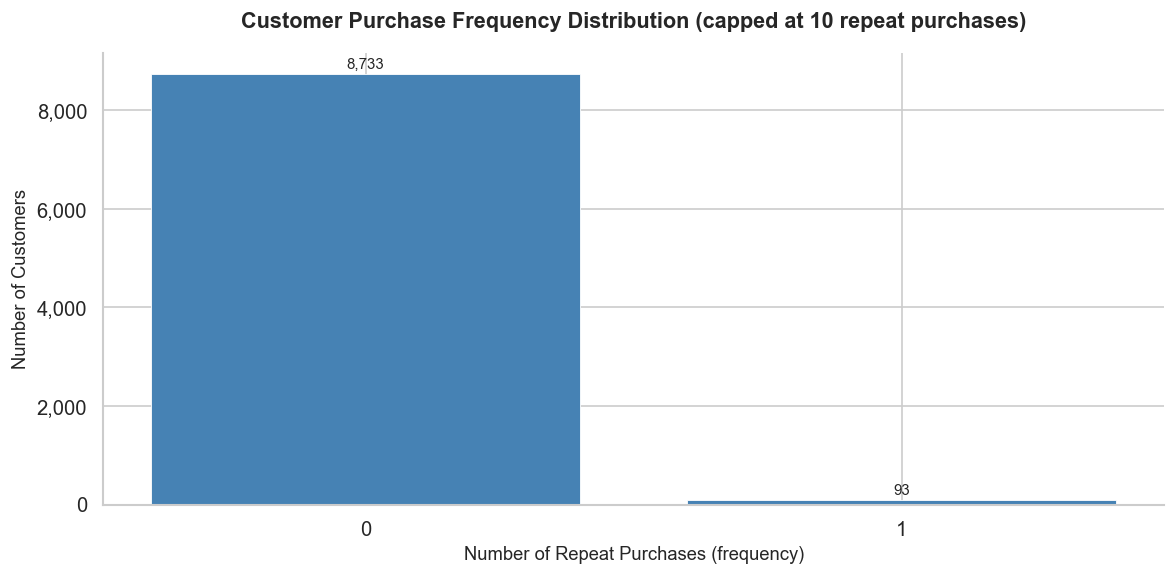

In [7]:
# Visualise frequency distribution
fig, ax = plt.subplots(figsize=(10, 5))

plot_data = summary[summary['frequency'] <= 10]['frequency'].value_counts().sort_index()

bars = ax.bar(plot_data.index, plot_data.values, color='steelblue', edgecolor='white', linewidth=0.5)

# Annotate each bar with count
for bar, val in zip(bars, plot_data.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

ax.set_title('Customer Purchase Frequency Distribution (capped at 10 repeat purchases)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of Repeat Purchases (frequency)', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(plot_data.index)
sns.despine()
plt.tight_layout()
save_figure(fig, '02_02_frequency_distribution.png')
plt.show()

## Fit the BG/NBD Model

In [8]:
#  Fit BG/NBD model
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

print('BG/NBD model fitted successfully.')
print(f'\nModel parameters:')
print(bgf.summary)

BG/NBD model fitted successfully.

Model parameters:
               coef      se(coef)  lower 95% bound  upper 95% bound
r      5.659371e-03  1.101518e-03     3.500395e-03     7.818347e-03
alpha  7.240416e+00  2.736702e+00     1.876480e+00     1.260435e+01
a      9.238514e-05  4.817073e-02    -9.432225e-02     9.450702e-02
b      4.743550e-10  2.460417e-07    -4.817674e-07     4.827161e-07


Figure saved → reports/figures/02_02_frequency_recency_matrix.png


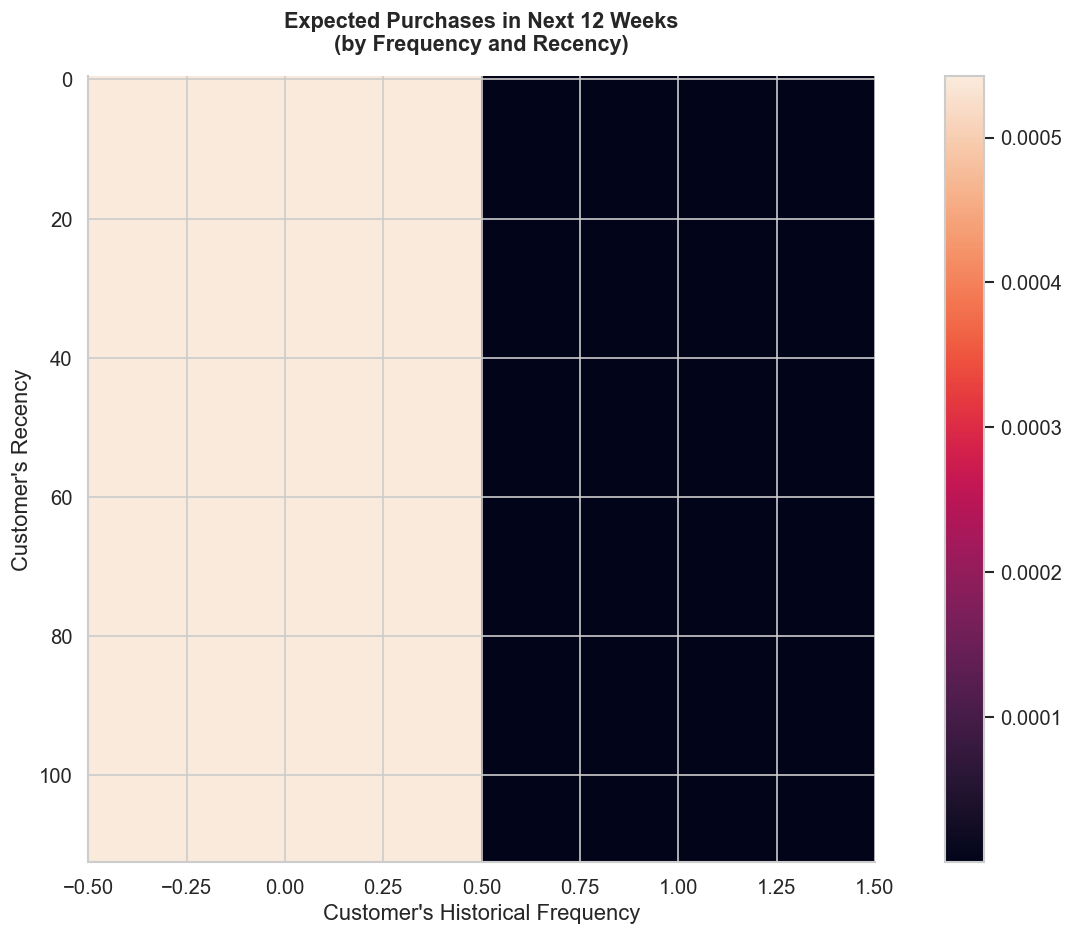

In [9]:
#  Visualise: Frequency × Recency matrix 
# What this shows: expected number of future purchases in the next 12 weeks
# for a customer based purely on their frequency and recency.
# High frequency + recent last purchase = top-right = most valuable.

fig, ax = plt.subplots(figsize=(12, 8))
plt.sca(ax)

plot_frequency_recency_matrix(bgf, T=12)

ax = plt.gca()
ax.set_title('Expected Purchases in Next 12 Weeks\n(by Frequency and Recency)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
save_figure(fig, '02_02_frequency_recency_matrix.png')
plt.show()

Figure saved → reports/figures/02_02_probability_alive_matrix.png


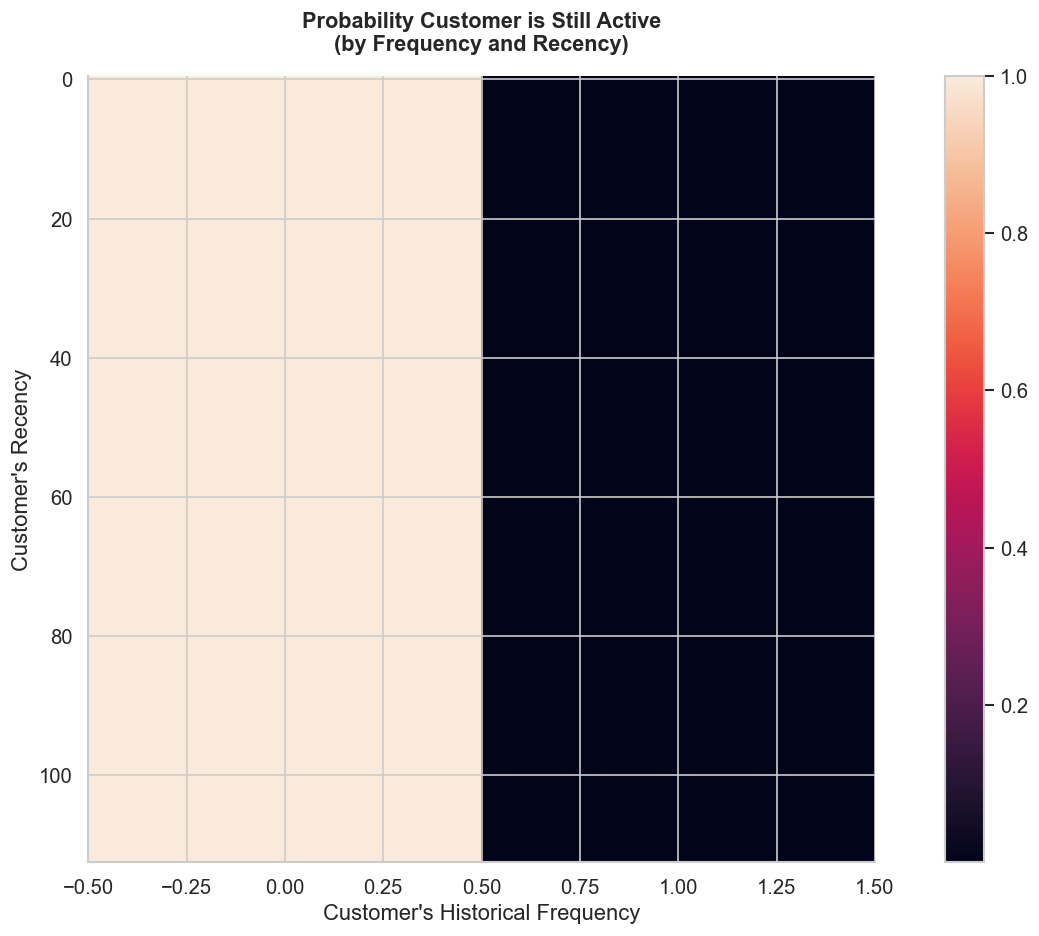

In [10]:
#  Visualise: Probability Alive matrix  
# What this shows: for a given frequency/recency combination, what is the
# probability the customer is still active (hasn't churned)?
# A customer who bought frequently but not recently is likely churned.
# A customer who bought recently (even once) is likely still alive.

fig, ax = plt.subplots(figsize=(12, 8))
plt.sca(ax)

plot_probability_alive_matrix(bgf)

ax = plt.gca()
ax.set_title('Probability Customer is Still Active\n(by Frequency and Recency)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
save_figure(fig, '02_02_probability_alive_matrix.png')
plt.show()

/Users/seleteakpotosu-nartey/anaconda3/envs/gamezone-analytics/lib/python3.11/site-packages/lifetimes/generate_data.py:54: RuntimeWarning: divide by zero encountered in scalar divide
  next_purchase_in = random.exponential(scale=1.0 / l)
/Users/seleteakpotosu-nartey/anaconda3/envs/gamezone-analytics/lib/python3.11/site-packages/lifetimes/generate_data.py:54: RuntimeWarning: overflow encountered in scalar divide
  next_purchase_in = random.exponential(scale=1.0 / l)


Figure saved → reports/figures/02_02_model_validation.png


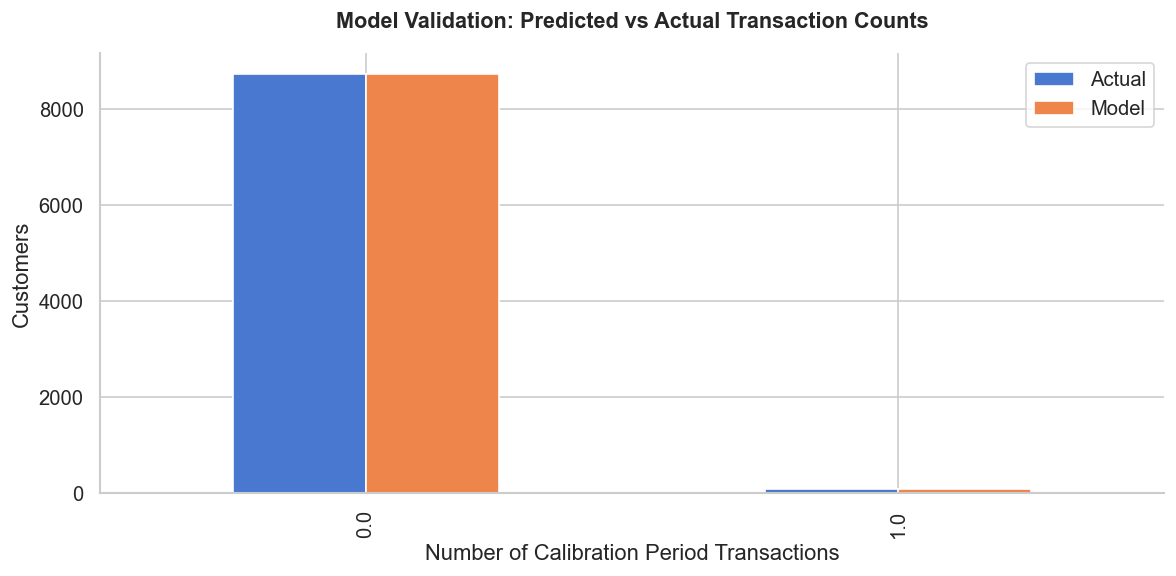

In [11]:
#  Model validation: predicted vs actual transaction counts ─
# Why validate? Fitting a model is not the same as having a good model.
# This plot compares what the model predicts the frequency distribution
# should look like vs what was actually observed in the data.
# If the bars align closely, the model has captured the real patterns.

fig, ax = plt.subplots(figsize=(10, 5))
plot_period_transactions(bgf, ax=ax)
ax.set_title('Model Validation: Predicted vs Actual Transaction Counts',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
save_figure(fig, '02_02_model_validation.png')
plt.show()

## Fit the Gamma-Gamma Spend Model

In [12]:
#  Filter to repeat buyers only  
returning_customers = summary[summary['frequency'] > 0]

print(f'Repeat buyers (frequency > 0): {len(returning_customers):,}')
print(f'One-time buyers excluded      : {len(summary) - len(returning_customers):,}')

#  Check frequency / monetary_value correlation 
corr = returning_customers[['frequency', 'monetary_value']].corr().iloc[0, 1]
print(f'\nCorrelation between frequency and monetary_value: {corr:.4f}')
if abs(corr) < 0.3:
    print('✓ Correlation is low — Gamma-Gamma assumption satisfied.')
else:
    print('Correlation is higher than expected — interpret Gamma-Gamma results with caution.')

Repeat buyers (frequency > 0): 93
One-time buyers excluded      : 8,733

Correlation between frequency and monetary_value: nan
Correlation is higher than expected — interpret Gamma-Gamma results with caution.


In [13]:
#  Fit Gamma-Gamma model  
ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(returning_customers['frequency'], returning_customers['monetary_value'])

print('Gamma-Gamma model fitted successfully.')
print(f'\nModel parameters:')
print(ggf.summary)

Gamma-Gamma model fitted successfully.

Model parameters:
        coef  se(coef)  lower 95% bound  upper 95% bound
p  10.462165  1.439810         7.640138        13.284192
q   0.741226  0.094991         0.555043         0.927410
v  10.291740  1.511090         7.330004        13.253477


## Calculate Predicted CLV

In [14]:
#  Calculate CLV for repeat buyers  
# Why only repeat buyers? The Gamma-Gamma spend model was fitted on repeat
# buyers only. We cannot make spend predictions for customers it never saw.
# One-time buyers will be handled separately below.

clv_repeat = ggf.customer_lifetime_value(
    bgf,
    returning_customers['frequency'],
    returning_customers['recency'],
    returning_customers['T'],
    returning_customers['monetary_value'],
    time=3,              # 3 months = ~12 weeks
    freq='W',
    discount_rate=0.01   # 1% monthly discount rate
).reset_index()

clv_repeat.columns = ['USER_ID', 'predicted_clv']
print(f'CLV calculated for {len(clv_repeat):,} repeat buyers')
print(f'\nCLV distribution:')
print(clv_repeat['predicted_clv'].describe().round(2))

CLV calculated for 93 repeat buyers

CLV distribution:
count    93.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: predicted_clv, dtype: float64


In [15]:
#  Handle one-time buyers  ─
# One-time buyers have no repeat purchase history so the Gamma-Gamma model
# cannot estimate their spend. We still predict their future purchase
# probability using BG/NBD alone, but set monetary prediction to NaN.
# This is honest — we don't know their spend pattern yet.

one_time_buyers = summary[summary['frequency'] == 0].copy()
one_time_buyers['predicted_purchases_12w'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    12,
    one_time_buyers['frequency'],
    one_time_buyers['recency'],
    one_time_buyers['T']
)
one_time_buyers['predicted_clv'] = np.nan
one_time_buyers = one_time_buyers.reset_index()[['USER_ID', 'predicted_purchases_12w', 'predicted_clv']]

print(f'One-time buyers: {len(one_time_buyers):,}')
print(f'Avg predicted purchases in 12 weeks (one-time buyers): {one_time_buyers["predicted_purchases_12w"].mean():.4f}')

One-time buyers: 8,733
Avg predicted purchases in 12 weeks (one-time buyers): 0.0015


In [16]:
#  Add predicted purchase count to repeat buyers too ─
clv_repeat['predicted_purchases_12w'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    12,
    returning_customers['frequency'],
    returning_customers['recency'],
    returning_customers['T']
).values

#  Add probability alive to all customers 
summary['prob_alive'] = bgf.conditional_probability_alive(
    summary['frequency'],
    summary['recency'],
    summary['T']
)

print('Predicted purchases and probability alive calculated for all customers.')
print(f'\nProb alive distribution:')
print(summary['prob_alive'].describe().round(4))

Predicted purchases and probability alive calculated for all customers.

Prob alive distribution:
count    8826.0000
mean        0.9895
std         0.1021
min         0.0000
25%         1.0000
50%         1.0000
75%         1.0000
max         1.0000
Name: prob_alive, dtype: float64


## Merge CLV with RFM Segments

In [17]:
#  Combine repeat and one-time buyer CLV tables 
clv_all = pd.concat([
    clv_repeat[['USER_ID', 'predicted_clv', 'predicted_purchases_12w']],
    one_time_buyers[['USER_ID', 'predicted_clv', 'predicted_purchases_12w']]
], ignore_index=True)

#  Merge probability alive from summary ─
summary_reset = summary.reset_index()[['USER_ID', 'frequency', 'recency', 'T', 'monetary_value', 'prob_alive']]
clv_all = clv_all.merge(summary_reset, on='USER_ID', how='left')

#  Merge RFM segment labels  
# Why merge with rfm_segments? We want CLV predictions AND the human-readable
# segment labels (Champions, Loyal, At Risk, Lapsed) in one place so we can
# answer business questions like: "Do Champions have the highest predicted CLV?"

rfm_cols = ['USER_ID', 'segment', 'recency', 'frequency', 'monetary', 'RFM_score']
clv_full = clv_all.merge(rfm[rfm_cols], on='USER_ID', how='left')

print(f'Final CLV table shape: {clv_full.shape}')
print(f'\nColumn list:')
print(clv_full.columns.tolist())
print(f'\nFirst 5 rows:')
print(clv_full.head())

Final CLV table shape: (8826, 13)

Column list:
['USER_ID', 'predicted_clv', 'predicted_purchases_12w', 'frequency_x', 'recency_x', 'T', 'monetary_value', 'prob_alive', 'segment', 'recency_y', 'frequency_y', 'monetary', 'RFM_score']

First 5 rows:
    USER_ID  predicted_clv  predicted_purchases_12w  frequency_x  recency_x  \
0  02dc501e       0.000217             6.121638e-07          1.0       43.0   
1  088e75cd       0.000037             1.030336e-07          1.0        8.0   
2  098ce0a4       0.000032             8.028236e-08          1.0        1.0   
3  0a350e95       0.000113             2.734307e-07          1.0       25.0   
4  0b9a9fd6       0.001025             1.538178e-06          1.0        4.0   

      T  monetary_value    prob_alive    segment  recency_y  frequency_y  \
0  64.0          313.84  3.613834e-06  Champions      152.0            3   
1  88.0          322.56  8.131538e-07  Champions      567.0            2   
2  72.0          354.03  5.271575e-07  Champions 

In [18]:
#  CLV by segment — summary table  ─
# This is the core business output of the notebook.
# We're asking: does the probabilistic model agree with our RFM segmentation?
# If Champions have the highest predicted CLV, that validates both approaches.

segment_clv = clv_full.groupby('segment').agg(
    customer_count=('USER_ID', 'count'),
    avg_predicted_clv=('predicted_clv', 'mean'),
    median_predicted_clv=('predicted_clv', 'median'),
    avg_prob_alive=('prob_alive', 'mean'),
    avg_predicted_purchases=('predicted_purchases_12w', 'mean')
).round(4)

segment_clv['avg_predicted_clv'] = segment_clv['avg_predicted_clv'].apply(
    lambda x: f'${x:,.2f}' if pd.notna(x) else 'N/A'
)
segment_clv['median_predicted_clv'] = segment_clv['median_predicted_clv'].apply(
    lambda x: f'${x:,.2f}' if pd.notna(x) else 'N/A'
)

print('CLV by Segment:')
print(segment_clv.to_string())

CLV by Segment:
                 customer_count avg_predicted_clv median_predicted_clv  avg_prob_alive  avg_predicted_purchases
segment                                                                                                        
At Risk                    5396               N/A                  N/A          1.0000                   0.0017
Champions                   779             $0.00                $0.00          0.8935                   0.0015
Lapsed                     2011               N/A                  N/A          1.0000                   0.0007
Loyal Customers             640             $0.00                $0.00          0.9844                   0.0016


## Visualisations

Figure saved → reports/figures/02_02_clv_by_segment_boxplot.png


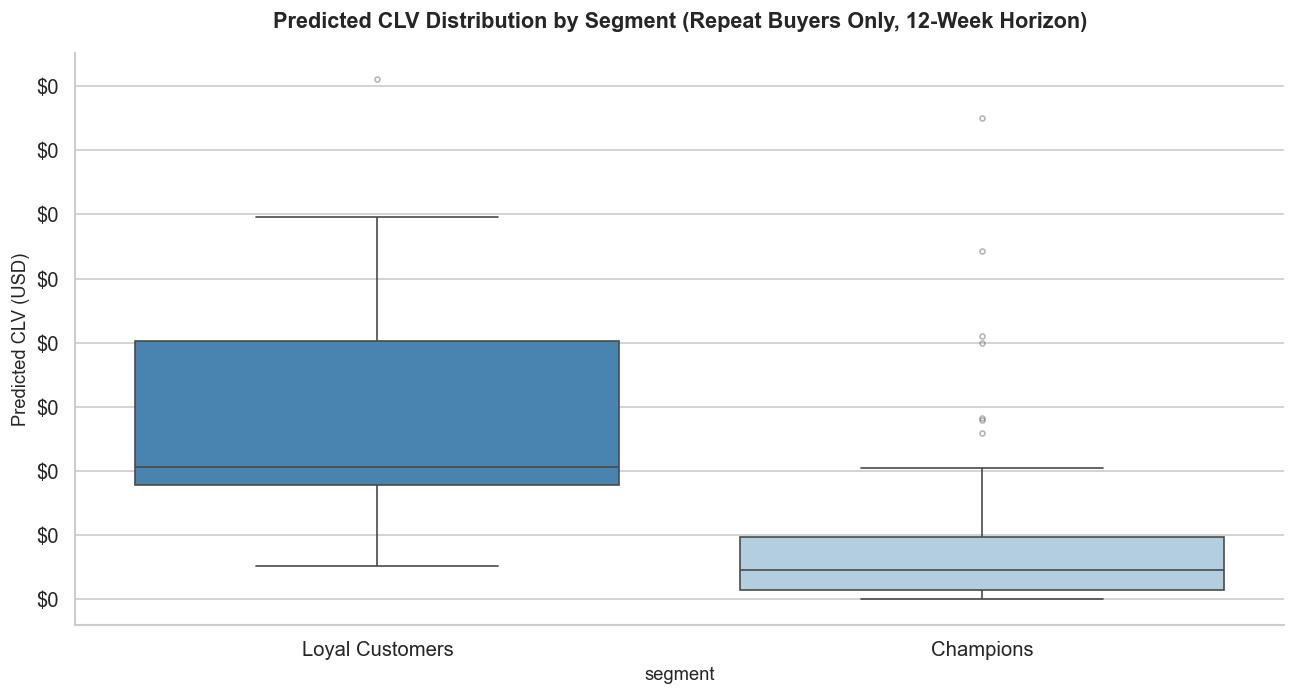

In [22]:
#  Fig 5: Predicted CLV distribution by segment (box plot) 
# Box plots are ideal here because CLV will be heavily right-skewed.
# A bar chart of means would be misleading — one very high CLV customer
# could pull the average up. The box shows median, IQR, and outliers.

clv_repeat_only = clv_full[clv_full['predicted_clv'].notna()]

segment_order = clv_repeat_only.groupby('segment')['predicted_clv'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=clv_repeat_only,
    x='segment', y='predicted_clv',
    order=segment_order,
    palette='Blues_r',
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)
ax.set_title('Predicted CLV Distribution by Segment (Repeat Buyers Only, 12-Week Horizon)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('segment', fontsize=11)
ax.set_ylabel('Predicted CLV (USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine()
plt.tight_layout()
save_figure(fig, '02_02_clv_by_segment_boxplot.png')
plt.show()

Figure saved → reports/figures/02_02_prob_alive_by_segment.png


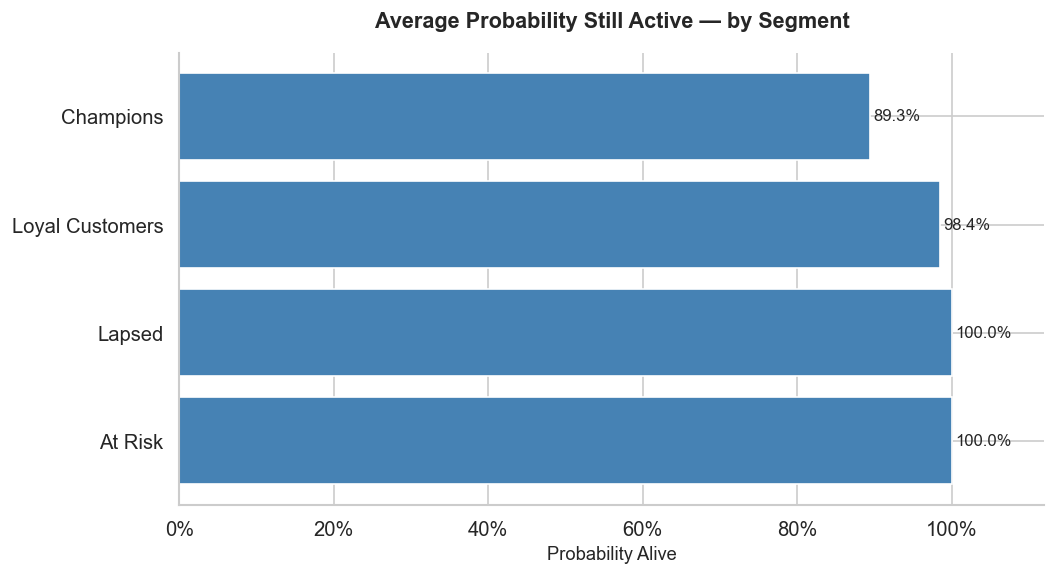

In [24]:
#  Fig 6: Probability alive by segment  
# This answers: which segments does the model believe are still active?
# High prob_alive = customer is likely to purchase again.
# A segment with high RFM score but low prob_alive is a red flag.

fig, ax = plt.subplots(figsize=(9, 5))

prob_alive_means = clv_full.groupby('segment')['prob_alive'].mean().sort_values(ascending=False)

bars = ax.barh(prob_alive_means.index, prob_alive_means.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, prob_alive_means.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}', va='center', fontsize=10)

ax.set_title('Average Probability Still Active — by Segment',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Probability Alive', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlim(0, 1.12)
sns.despine()
plt.tight_layout()
save_figure(fig, '02_02_prob_alive_by_segment.png')
plt.show()

Figure saved → reports/figures/02_02_predicted_purchases_by_segment.png


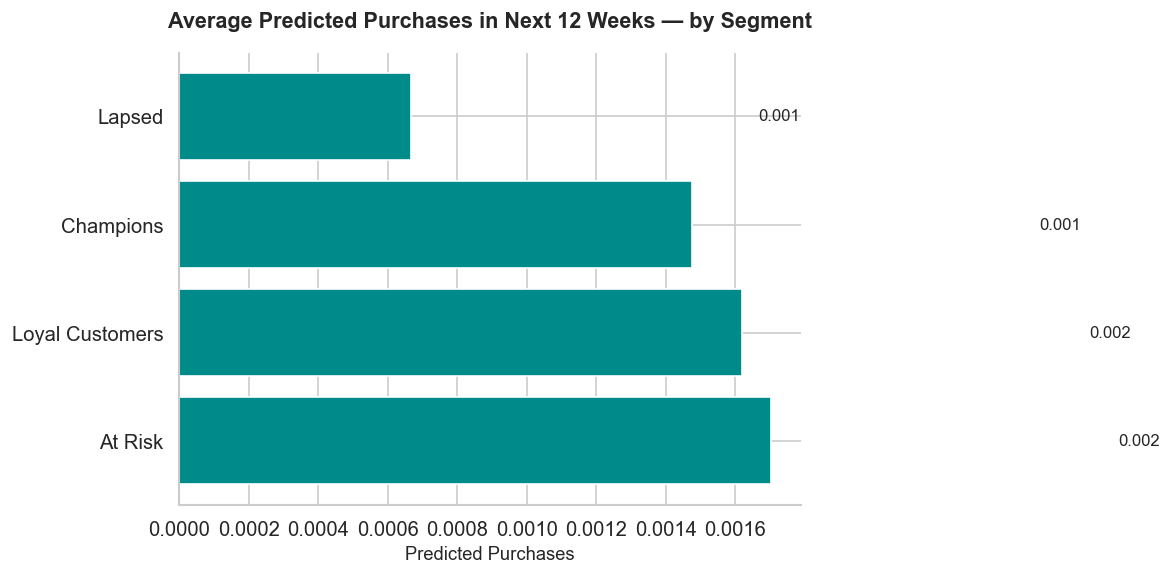

In [25]:
#  Fig 7: Predicted purchases in 12 weeks by segment 
fig, ax = plt.subplots(figsize=(9, 5))

purchase_means = clv_full.groupby('segment')['predicted_purchases_12w'].mean().sort_values(ascending=False)

bars = ax.barh(purchase_means.index, purchase_means.values, color='darkcyan', edgecolor='white')
for bar, val in zip(bars, purchase_means.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Average Predicted Purchases in Next 12 Weeks — by Segment',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Purchases', fontsize=11)
sns.despine()
plt.tight_layout()
save_figure(fig, '02_02_predicted_purchases_by_segment.png')
plt.show()

Figure saved → reports/figures/02_02_clv_vs_prob_alive_scatter.png


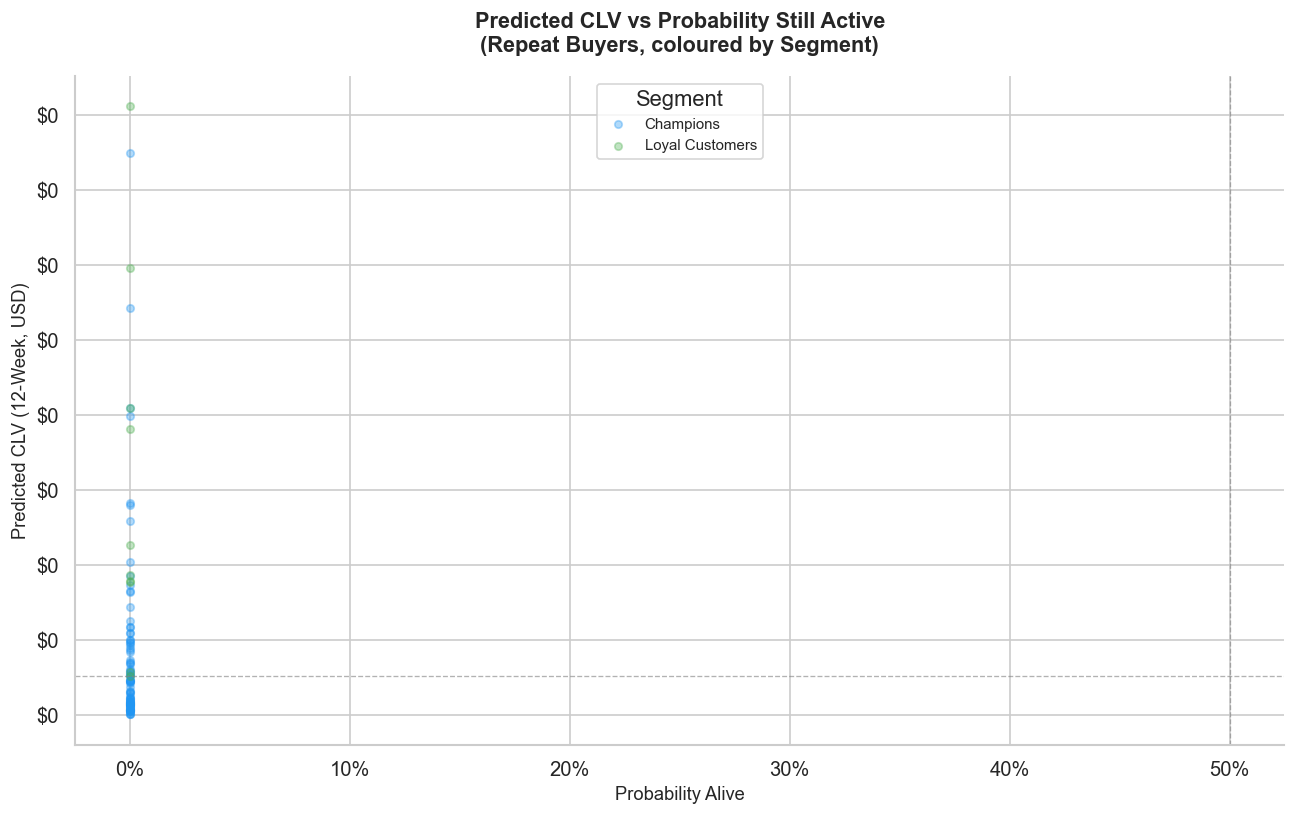

In [26]:
#  Fig 8: CLV vs Probability Alive scatter (repeat buyers) 
# This is the most actionable chart for a marketing team.
# Four quadrants emerge:
#   High CLV + High alive  → Protect these customers (Champions/Loyal)
#   High CLV + Low alive   → Win-back campaign urgently
#   Low CLV  + High alive  → Upsell / nurture
#   Low CLV  + Low alive   → Low priority

palette = {'Champions': '#2196F3', 'Loyal Customers': '#4CAF50',
           'At Risk': '#FF9800', 'Lapsed': '#F44336'}

fig, ax = plt.subplots(figsize=(11, 7))

for seg, grp in clv_repeat_only.groupby('segment'):
    ax.scatter(grp['prob_alive'], grp['predicted_clv'],
               alpha=0.35, s=20, label=seg, color=palette.get(seg, 'grey'))

# Quadrant lines at median values
med_clv = clv_repeat_only['predicted_clv'].median()
ax.axhline(med_clv, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_title('Predicted CLV vs Probability Still Active\n(Repeat Buyers, coloured by Segment)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Probability Alive', fontsize=11)
ax.set_ylabel('Predicted CLV (12-Week, USD)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Segment', fontsize=9)
sns.despine()
plt.tight_layout()
save_figure(fig, '02_02_clv_vs_prob_alive_scatter.png')
plt.show()

## Export

In [27]:
os.makedirs(processed_path, exist_ok=True)

# Export CLV predictions 
output_path = processed_path/ 'clv_predictions.csv'
clv_full.to_csv(output_path, index=False)

print(f'Exported: {output_path}')
print(f'Rows: {len(clv_full):,}')
print(f'Columns: {clv_full.columns.tolist()}')
print(f'\nNulls in predicted_clv (one-time buyers): {clv_full["predicted_clv"].isna().sum():,}')
print(f'\nSample output:')
print(clv_full.head(10).to_string())

Exported: /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Gamezone/gamezone-analytics/data/processed/clv_predictions.csv
Rows: 8,826
Columns: ['USER_ID', 'predicted_clv', 'predicted_purchases_12w', 'frequency_x', 'recency_x', 'T', 'monetary_value', 'prob_alive', 'segment', 'recency_y', 'frequency_y', 'monetary', 'RFM_score']

Nulls in predicted_clv (one-time buyers): 8,733

Sample output:
    USER_ID  predicted_clv  predicted_purchases_12w  frequency_x  recency_x     T  monetary_value    prob_alive          segment  recency_y  frequency_y  monetary  RFM_score
0  02dc501e       0.000217             6.121638e-07          1.0       43.0  64.0          313.84  3.613834e-06        Champions      152.0            3    633.04   4.666667
1  088e75cd       0.000037             1.030336e-07          1.0        8.0  88.0          322.56  8.131538e-07        Champions      567.0            2    490.56   3.333333
2  098ce0a4       0.000032             8.028236e-08          1.0        1.0  72.0   